# Setup


In [102]:
import os 
import numpy as np 
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets,transforms,models
from torch.optim.lr_scheduler import StepLR
from torchinfo import summary
from tqdm import tqdm
 

In [103]:
# import kagglehub
# import shutil

# # Download latest version
# path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
# shutil.move(path, "./chest-xray-pneumonia")
# print("The dataset has been moved to your working directory: ", path)

### Create Datasets and DataLoaders

In [104]:
from pathlib import Path

data_path = Path('chest-xray-pneumonia/chest_xray')
train_dir = data_path / "train"
test_dir = data_path / "test"
val_dir = data_path / "val" 

train_dir, test_dir, val_dir

(WindowsPath('chest-xray-pneumonia/chest_xray/train'),
 WindowsPath('chest-xray-pneumonia/chest_xray/test'),
 WindowsPath('chest-xray-pneumonia/chest_xray/val'))

### Xray Images Before tranformation

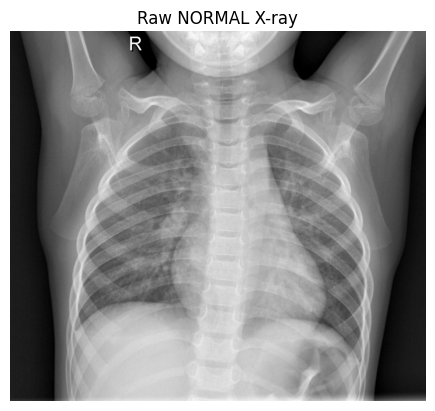

In [105]:
# View raw images before transforms
import os

# Get a raw NORMAL image
normal_files = os.listdir(train_dir / "NORMAL")
img_path = train_dir / "NORMAL" / normal_files[0]
raw_img = Image.open(img_path)
plt.imshow(raw_img, cmap='gray')  # X-rays are grayscale
plt.title("Raw NORMAL X-ray")
plt.axis("off")
plt.show()



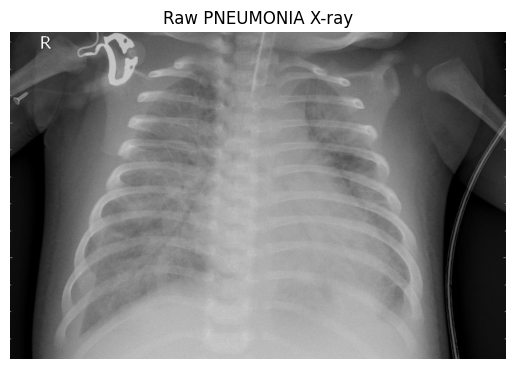

In [106]:
# Get a raw PNEUMONIA image
pneumonia_files = os.listdir(train_dir / "PNEUMONIA")
img_path = train_dir / "PNEUMONIA" / pneumonia_files[0]
raw_img = Image.open(img_path)
plt.imshow(raw_img, cmap='gray')
plt.title("Raw PNEUMONIA X-ray")
plt.axis("off")
plt.show()

In [107]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])

])

In [108]:
train_data = datasets.ImageFolder(train_dir,transform=train_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)
val_data = datasets.ImageFolder(val_dir, transform=test_transform)


class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')
print(f'Number of validation images: {len(val_data)}')


['NORMAL', 'PNEUMONIA']
Number of train images: 5216
Number of test images: 624
Number of validation images: 16


### Xray images after transformation

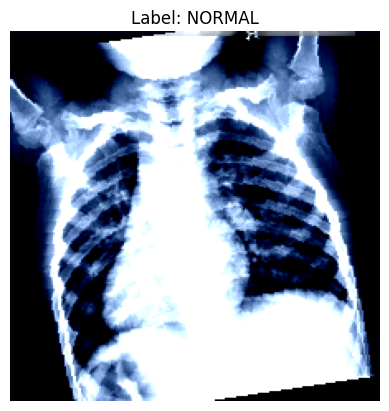

In [109]:
# Sample one image from the training dataset
image, label = train_data[0]

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image.permute(1,2,0)
image = image.numpy() # Convert the image from tensor to numpy 
for i in range(3):
    image[i] = image[i] * std[i] + mean[i]
    
image = image.clip(0,1)
plt.imshow(image)
plt.title(f"Label: {'NORMAL' if label == 0 else 'PNEUMONIA' }")
plt.axis("off")
plt.show()




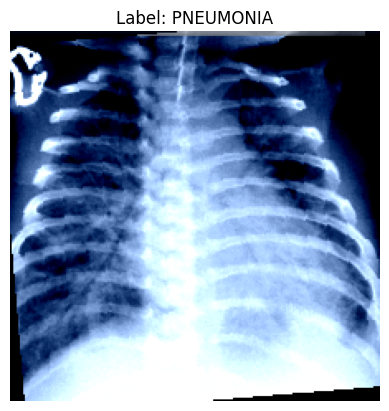

In [110]:
# Find and visualize a PNEUMONIA image from train_data (one-liner)
image, label = next((train_data[i] for i in range(len(train_data)) if train_data[i][1] == 1))

# Denormalize on the tensor
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image.permute(1,2,0)
image = image.numpy() # Convert the image from tensor to numpy 
for i in range(3):
    image[i] = image[i] * std[i] + mean[i]
    
image = image.clip(0,1)
plt.imshow(image)
plt.title(f"Label: {'NORMAL' if label == 0 else 'PNEUMONIA' }")
plt.axis("off")
plt.show()

In [111]:
batch_size = 16

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=batch_size,
                              shuffle=True,
                              pin_memory=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=batch_size,
                             shuffle=False,
                             pin_memory=True
                             )
val_dataloader = DataLoader(dataset=val_data,
                             batch_size=batch_size,
                             shuffle=False,
                             pin_memory=True
                             )
print(class_names)
len(train_dataloader),len(test_dataloader),len(val_dataloader)


['NORMAL', 'PNEUMONIA']


(326, 39, 1)

# Model Creation


In [112]:
import torch.nn.functional as F
class xrayclassifier(nn.Module):
    def __init__(self):
        super(xrayclassifier, self).__init__()
        # Input Block 1
        self.pool = nn.MaxPool2d(2) # will be used 3 times
        self.convblock1 = nn.Sequential(
            nn.Conv2d(in_channels=3,
                      out_channels=8,
                      kernel_size=3,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        # Conv Block 2
        self.convblock2 = nn.Sequential(
            nn.Conv2d(in_channels=8,
                      out_channels=16,
                      kernel_size=3,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        self.convblock3 = nn.Sequential(
            nn.Conv2d(in_channels=16,
                      out_channels=10,
                      kernel_size=1,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        ) 
        self.convblock4 = nn.Sequential(
            nn.Conv2d(in_channels=10,
                      out_channels=10,
                      kernel_size=3,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convblock5 = nn.Sequential(
            nn.Conv2d(in_channels=10,
                      out_channels=32,
                      kernel_size=1,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(32)
        )
        self.convblock6 = nn.Sequential(
            nn.Conv2d(in_channels=32,
                      out_channels=10,
                      kernel_size=1,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convblock7 = nn.Sequential(
            nn.Conv2d(in_channels=10,
                      out_channels=10,
                      kernel_size=3,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convblock8 = nn.Sequential(
            nn.Conv2d(in_channels=10,
                      out_channels=32,
                      kernel_size=1,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(32)
        )
        self.convblock9 = nn.Sequential(
            nn.Conv2d(in_channels=32,
                      out_channels=10,
                      kernel_size=1,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convblock10 = nn.Sequential(
            nn.Conv2d(in_channels=10,
                      out_channels=14,
                      kernel_size=3,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )
        self.convblock11 = nn.Sequential(
            nn.Conv2d(in_channels=14,
                      out_channels=16,
                      kernel_size=3,
                      padding=0,
                      bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        # Output Block
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )
        self.convblockout = nn.Sequential(
            nn.Conv2d(in_channels=16,
                      out_channels=2,
                      kernel_size=4,
                      padding=0,
                      bias=False)
        )
    def forward(self,x):
        x = self.convblock1(x)
        x = self.pool(x)
        x = self.convblock2(x)
        x = self.pool(x)
        x = self.convblock3(x)
        x = self.pool(x)
        x = self.convblock4(x)
        x = self.convblock5(x)
        x = self.convblock6(x)
        x = self.convblock7(x)
        x = self.convblock8(x)
        x = self.convblock9(x)
        x = self.convblock10(x)
        x = self.convblock11(x)
        x = self.gap(x)
        x = self.convblockout(x)
        
        x = x.view(-1,2)
        
        return F.log_softmax(x, dim=-1)        
        
        
        
        

In [113]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [114]:
model = xrayclassifier().to(device)
summary(model, input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
xrayclassifier (xrayclassifier)          [1, 3, 224, 224]     [1, 2]               --                   True
├─Sequential (convblock1)                [1, 3, 224, 224]     [1, 8, 222, 222]     --                   True
│    └─Conv2d (0)                        [1, 3, 224, 224]     [1, 8, 222, 222]     216                  True
│    └─ReLU (1)                          [1, 8, 222, 222]     [1, 8, 222, 222]     --                   --
│    └─BatchNorm2d (2)                   [1, 8, 222, 222]     [1, 8, 222, 222]     16                   True
├─MaxPool2d (pool)                       [1, 8, 222, 222]     [1, 8, 111, 111]     --                   --
├─Sequential (convblock2)                [1, 8, 111, 111]     [1, 16, 109, 109]    --                   True
│    └─Conv2d (0)                        [1, 8, 111, 111]     [1, 16, 109, 109]    1,152                True
│    └─ReLU (1)   

In [115]:
from typing import Dict, List, Tuple

import torch

from tqdm.auto import tqdm



def train_step(model, dataloader, loss_fn, optimizer, device, l1=0, lambda1=1e-3):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0  # ← track raw counts, not running avg

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)

        loss = loss_fn(y_pred, y)

        # L1 always applied (matching his behavior)
        l1_penalty = 0
        for p in model.parameters():
            l1_penalty += p.abs().sum()
        loss = loss + lambda1 * l1_penalty

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += y_pred.argmax(dim=1).eq(y).sum().item()  # ← raw count
        train_total += len(y)                                      # ← raw count

    return train_loss / len(dataloader), train_correct / train_total  


def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
    model.eval()
    test_loss, test_acc = 0, 0
    
    with torch.inference_mode():
        for batch, (x,y) in enumerate(dataloader):
            x,y = x.to(device),y.to(device)
            
            test_pred_logits = model(x)
            
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def val_step(model: torch.nn.Module, 
             dataloader: torch.utils.data.DataLoader, 
             loss_fn: torch.nn.Module,
             device: torch.device) -> Tuple[float, float]:
    model.eval()
    val_loss, val_acc = 0, 0
    
    with torch.inference_mode():
        for batch, (x,y) in enumerate(dataloader):
            x,y = x.to(device),y.to(device)
            
            val_pred_logits = model(x)
            
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()
            
            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += ((val_pred_labels == y).sum().item()/len(val_pred_labels))
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc

In [116]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          val_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          l1: float = 0,
          lambda1: float = 1e-3,
          step_size: int = 6,
          gamma: float = 0.5) -> Dict[str, List[float]]:

    
    scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

    results = {"train_loss": [],
               "train_acc": [],
               "val_loss": [],
               "val_acc": [],
               "test_loss": [],
               "test_acc": []}
    
    for epoch in tqdm(range(epochs)):
        model.train()
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device,
                                           l1=l1,
                                           lambda1=lambda1)
        val_loss, val_acc = val_step(model=model,
                                     dataloader=val_dataloader,
                                     loss_fn=loss_fn,
                                     device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        scheduler.step()  # Step the scheduler each epoch
        current_lr = optimizer.state_dict()["param_groups"][0]["lr"]

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f} | "
            f"lr: {current_lr:.6f}"
        )
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

### Training part 


In [117]:
xray_model = xrayclassifier().to(device)
optimizer = torch.optim.SGD(xray_model.parameters(), lr=0.01, momentum=0.9)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)
loss_fn = torch.nn.NLLLoss()  # match his loss

results = train(model=xray_model,
                train_dataloader=train_dataloader,
                val_dataloader=val_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=15,
                device=device,
                lambda1=1e-3)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8891 | train_acc: 0.9055 | val_loss: 1.4115 | val_acc: 0.6875 | test_loss: 0.8092 | test_acc: 0.7324 | lr: 0.010000
Epoch: 2 | train_loss: 0.6874 | train_acc: 0.9387 | val_loss: 1.7777 | val_acc: 0.5625 | test_loss: 1.3427 | test_acc: 0.6795 | lr: 0.010000
Epoch: 3 | train_loss: 0.5754 | train_acc: 0.9434 | val_loss: 0.9545 | val_acc: 0.5625 | test_loss: 0.7615 | test_acc: 0.7516 | lr: 0.010000
Epoch: 4 | train_loss: 0.5307 | train_acc: 0.9398 | val_loss: 0.9246 | val_acc: 0.5625 | test_loss: 0.7114 | test_acc: 0.7885 | lr: 0.010000
Epoch: 5 | train_loss: 0.5002 | train_acc: 0.9410 | val_loss: 0.9681 | val_acc: 0.5625 | test_loss: 0.7344 | test_acc: 0.7452 | lr: 0.010000
Epoch: 6 | train_loss: 0.4888 | train_acc: 0.9381 | val_loss: 0.7277 | val_acc: 0.7500 | test_loss: 0.8458 | test_acc: 0.7388 | lr: 0.005000
Epoch: 7 | train_loss: 0.4363 | train_acc: 0.9505 | val_loss: 0.8589 | val_acc: 0.5625 | test_loss: 0.7004 | test_acc: 0.7388 | lr: 0.005000
Epoch: 8 | tr

### Plot the results

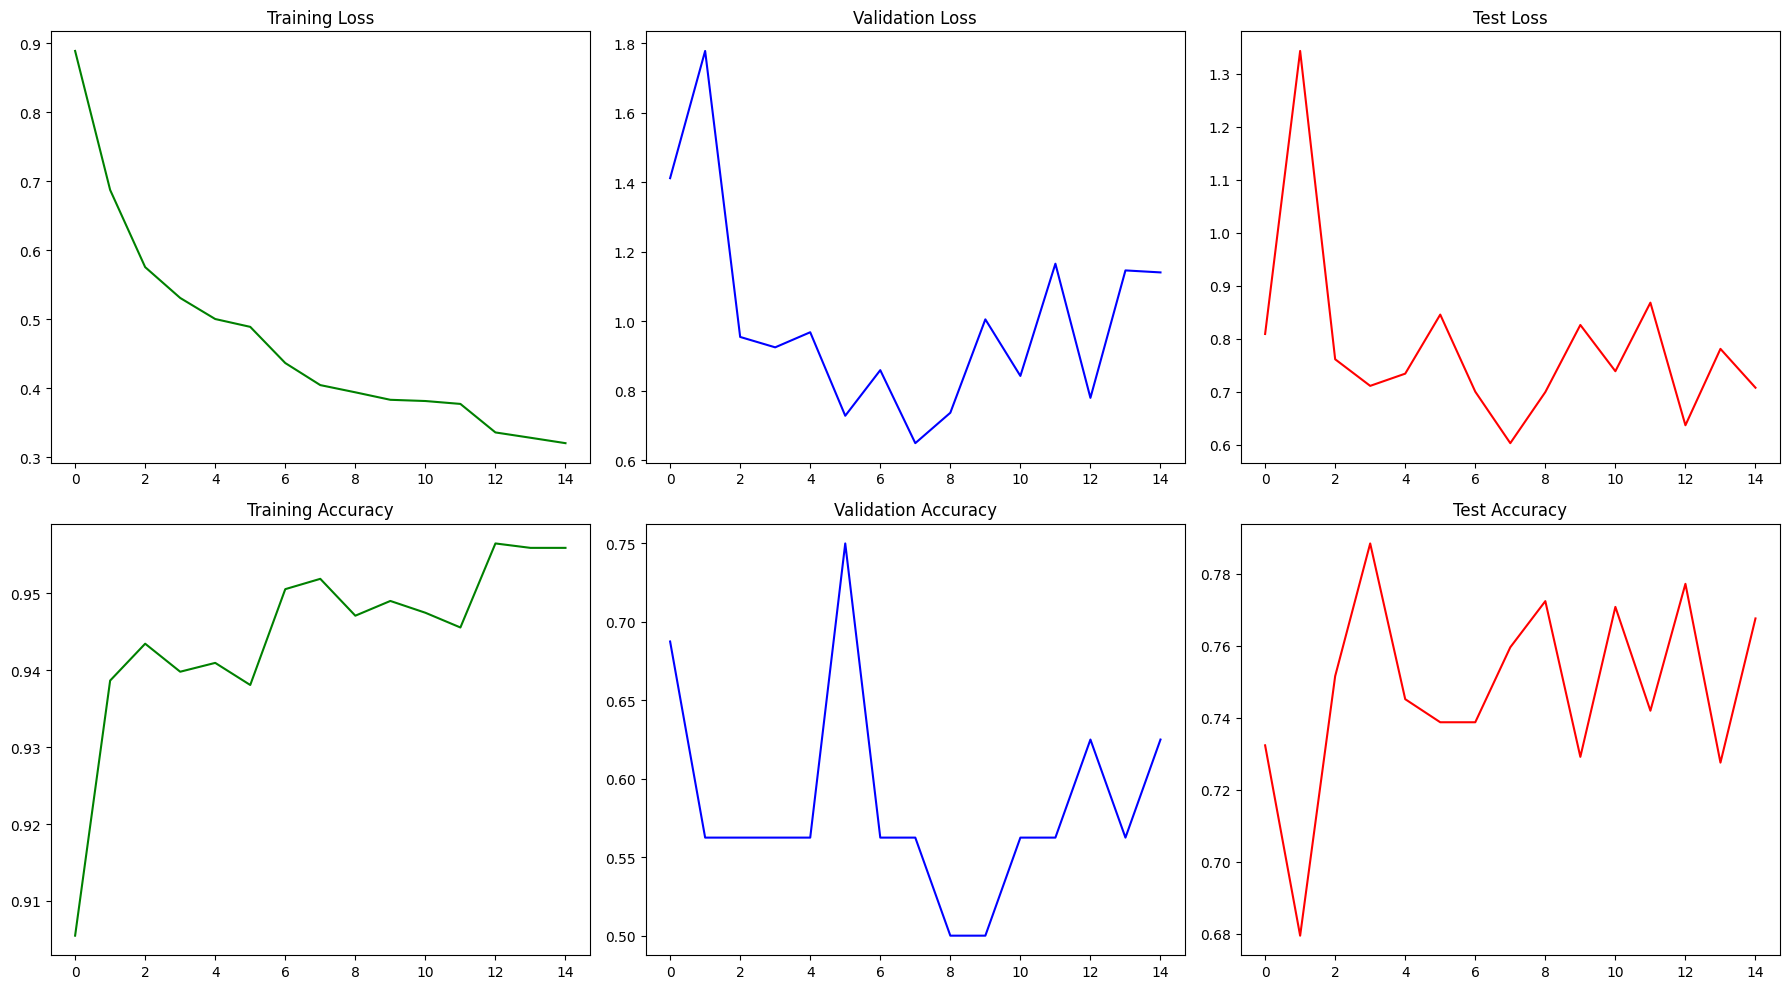

In [120]:
train_losses1 = [i for i in results["train_loss"]]
train_acc1 = [i for i in results["train_acc"]]
val_losses1 = [i for i in results["val_loss"]]
val_acc1 = [i for i in results["val_acc"]]
test_losses1 = [i for i in results["test_loss"]]
test_acc1 = [i for i in results["test_acc"]]

fig, axs = plt.subplots(2,3,figsize=(18,10))
axs[0, 0].plot(train_losses1,color='green')
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc1,color='green')
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(val_losses1,color='blue')
axs[0, 1].set_title("Validation Loss")
axs[1, 1].plot(val_acc1,color='blue')
axs[1, 1].set_title("Validation Accuracy")
axs[0, 2].plot(test_losses1,color='red')
axs[0, 2].set_title("Test Loss")
axs[1, 2].plot(test_acc1,color='red')
axs[1, 2].set_title("Test Accuracy")
plt.tight_layout()
plt.show()